# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [ ]:
# ===================================
# Useful Imports: Add more as needed
# ===================================
#
# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [ ]:
#import cleaned df from part 1 into df

df = pd.read_csv('Zillow_clean.csv')

In [ ]:
#Dictionary of selected models that we are testing, update with the ones you plan on using

selected_models = {
    'HistGradientBoosting': HistGradientBoostingRegressor,
    'Ridge': Ridge,
}

In [ ]:
# created train test split and chose to cap training data to .99 quantile. This removes the extremely expensive houses as outliers and provides an
# improvement to model performance for more average houses

scaler = StandardScaler()

X = df.drop(columns=['taxvaluedollarcnt'], axis= 1)
y = df['taxvaluedollarcnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Cap outliers in training set only. Test set stays untouched
cap = y_train.quantile(0.99)
print(f"99th percentile cap: ${cap:,.0f}")
print(f"Rows removed: {(y_train > cap).sum()} ({(y_train > cap).mean()*100:.2f}% of training data)")

X_train_full = X_train.copy()
y_train_full = y_train.copy()

mask = y_train <= cap
X_train = X_train[mask]
y_train = y_train[mask]


X_train_scaled = scaler.fit_transform(X_train)

99th percentile cap: $2,692,839
Rows removed: 618 (1.00% of training data)


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [ ]:
from sklearn.metrics import mean_absolute_error

def run_model(model, 
              X_train, y_train, 
              n_repeats=5, 
              n_jobs=-1, 
              **model_params
             ):

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:                                    
        model.set_params(**model_params)    

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model, 
        X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_state), 
        n_jobs=n_jobs
    )
    
    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)
    
    return mean_cv_mae, std_cv_mae, train_mae


In [ ]:
def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train,              # Defined above
                    y_train          = y_train,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = False,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):
    

    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  # Just in case
        
        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)
        
        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        if show_mae:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters

In [ ]:
baseline_model = HistGradientBoostingRegressor(random_state=random_state).fit(X_train_scaled,y_train)

baseline_cv_mae, baseline_std_mae, train_mae = run_model(   baseline_model,
                                                            X_train_scaled,
                                                            y_train,
                                                            n_repeats=5,
                                                            n_jobs=-1,
                                                                        )
print(f"Baseline CV MAE: ${baseline_cv_mae:,.0f} ± ${baseline_std_mae:,.0f}")
print(f"Baseline Train MAE: ${train_mae:,.0f}")


Baseline CV MAE: $165,709 ± $1,709
Baseline Train MAE: $158,086


In [ ]:
#Rigde Regression

ridge_cv_mae, ridge_std_mae, _ = run_model(
    Ridge,
    X_train_scaled,
    y_train,
    n_repeats=5,
    n_jobs=-1
)

print(f"Ridge Mean CV MAE: ${ridge_cv_mae:,.0f}")
print(f"Ridge Std CV MAE: ${ridge_std_mae:,.0f}")

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

> Your text here

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [ ]:
def feature_eng(X_train, X_test):
    
    def add_features(df:pd.DataFrame):
        df_eng = df.copy()

        #property age
        if 'yearbuilt' in df_eng.columns:
            df_eng['property_age'] = 2016 - df['yearbuilt']

        #ratios
        df_eng['sqft_per_bedroom'] = df['calculatedfinishedsquarefeet'] / df['bedroomcnt'].replace(0, 1)
        df_eng['bed_bath_ratio'] = df['bathroomcnt']/ (df['bedroomcnt'].replace(0, 1))

        #log transforms for skewed data
        skewed_features = ['calculatedfinishedsquarefeet', 'lotsizesquarefeet']
        for feature in skewed_features:
            if feature in df.columns:
                df_eng[f"log_{feature}"] = np.log1p(df[feature])

        #rounded lat and lon
        if all(col in df_eng.columns for col in ['latitude', 'longitude']):
            df_eng[['latitude_round','longitude_round']] = df[['latitude','longitude']].round(2)

        #removing redunant features after adding engineered features
        redundant_features = ['yearbuilt', 'latitude', 'longitude']
        for feature in redundant_features:
            if feature in df_eng:
                df_eng = df_eng.drop(columns=[feature])

        return df_eng
    
    X_train_eng = add_features(X_train)
    X_test_eng = add_features(X_test)

    return X_train_eng, X_test_eng

X_train_before_eng = X_train.copy()
X_train_baseline_scaled = X_train_scaled.copy()

X_train, X_test = feature_eng(X_train, X_test)


In [ ]:
# Running this cell will compare baseline models with default parameters from selected_models variable near the top, 

# no changes should be needed in this cell if it works right...

def compare(X_baseline, X_engineered, y_train, models, n_repeats = 5):
    scaler = StandardScaler()
    X_baseline_scaled = scaler.fit_transform(X_baseline)

    scaler2 = StandardScaler()
    X_engineered_scaled = scaler2.fit_transform(X_engineered)
    
    
    rows = []
    
    for name, model in models.items():
        base_mae, base_std, _ = run_model(model, X_baseline_scaled, y_train, n_repeats=n_repeats, random_state=random_state, n_jobs=-1)
        eng_mae,  eng_std,  _  = run_model(model, X_engineered_scaled,  y_train, n_repeats=n_repeats, random_state=random_state, n_jobs=-1)

        improvement = base_mae - eng_mae

        rows.append((name, base_mae, base_std, eng_mae, eng_std, improvement))

    print(f"\n{'Model':35} {'Baseline':>12}  {'± Std':>10}  {'Engineered':>12}  {'± Std':>10}  {'Change':>12}")

    for name, base, base_std, eng, eng_std, delta in rows:
        print(f"{name:35} ${base:>11,.0f}  ${base_std:>9,.0f}  ${eng:>11,.0f}  ${eng_std:>9,.0f}  ${delta:>+11,.0f}")


compare(X_train_before_eng, X_train_scaled, y_train, selected_models, n_repeats=5)




Model                                   Baseline       ± Std    Engineered       ± Std        Change
HistGradientBoosting                $    166,014  $    1,737  $    165,708  $    1,710  $       +305


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




> Your text here

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


#### Hist Gradient Boosting Trees

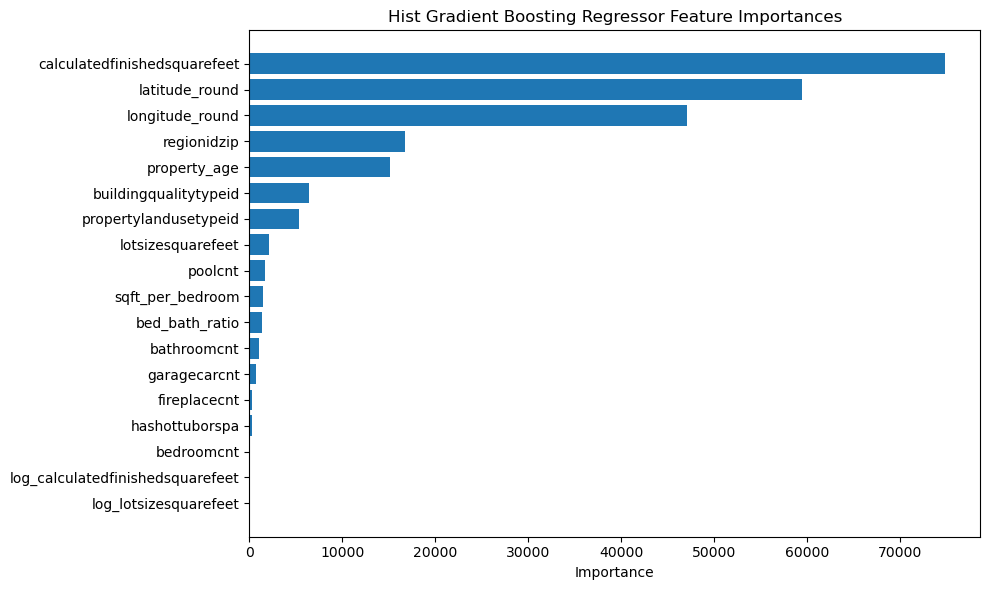

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

hist_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', HistGradientBoostingRegressor(random_state=random_state))
])

engineered_model = hist_pipeline.fit(X_train,y_train)

result = permutation_importance(
    engineered_model, 
    X_test, 
    y_test, 
    scoring='neg_mean_absolute_error', 
    n_repeats=5, 
    random_state=random_state, 
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importances.index,importances.values)
plt.gca().invert_yaxis()
plt.title("Hist Gradient Boosting Regressor Feature Importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_features(X_train, y_train, models, n_repeats=5):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    
    rows = []
    for name, model in models.items():
        mae, std, _ = run_model(model, X_scaled, y_train, n_repeats=n_repeats)
        rows.append((name, mae, std))

    print(f"\n{'Model':35} {'CV MAE':>12}  {'± Std':>10}")

    for name, mae, std in rows:
        print(f"{name:35} ${mae:>11,.0f}  ${std:>9,.0f}")


In [ ]:
hist_dict = {
    'HistGradientBoosting': HistGradientBoostingRegressor
}

In [ ]:
#get all the featurs with an importance over 0.01
top_features = importances[importances > 0.01].index.tolist()

X_train_selected = X_train[top_features]

evaluate_features(X_train_selected, y_train, hist_dict)


Model                                     CV MAE       ± Std
HistGradientBoosting                $    165,859  $    1,723


cutting features did not help much here, try cutting it down to just top 6

In [ ]:
#get just top 6 features
top_6_features = importances.nlargest(6).index.to_list()

X_train_selected = X_train[top_6_features]

evaluate_features(X_train_selected, y_train, hist_dict)



Model                                     CV MAE       ± Std
HistGradientBoosting                $    166,654  $    1,866


#### Ridge Regression

In [ ]:

scaler = StandardScaler()
X_train_eng_scaled = scaler.fit_transform(X_train)

# Forward feature
ridge_selector = SequentialFeatureSelector(
    Ridge(),
    direction='forward',
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

ridge_selector.fit(X_train_eng_scaled, y_train)

ridge_selected_features = X_train.columns[ridge_selector.get_support()]

In [ ]:
X_train_ridge_selected = X_train[ridge_selected_features]

scaler = StandardScaler()
X_train_ridge_selected_scaled = scaler.fit_transform(X_train_ridge_selected)

ridge_cv_mae, ridge_std_mae, ridge_train_mae = run_model(
    Ridge,
    X_train_ridge_selected_scaled,
    y_train,
    n_repeats=5,
    n_jobs=-1
)

print(f"CV MAE: ${ridge_cv_mae:,.0f} ± ${ridge_std_mae:,.0f}")
print(f"Train MAE: ${ridge_train_mae:,.0f}")

### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

#### Hist Gradient Boosting Trees

Will proceed with all features since HistGradientBoosting is good at feature selection on its own, and removing subsets of features seemed to have minimal impact

In [ ]:
parameter_list = {}
parameter_list_List = []

Default_Parameters_GB = {
    'model__max_iter'         : 100,
    'model__max_depth'        : None,
    'model__max_leaf_nodes'   : 31,
    'model__min_samples_leaf' : 20,
    'model__max_features'     : 1.0,
    'model__l2_regularization': 0.0,
    'model__random_state'     : random_state,
    'MAE_found'                          : float('inf')
}

Params_GB = Default_Parameters_GB.copy()


In [ ]:
#testing a log transform on target
from sklearn.compose import TransformedTargetRegressor

pipeline_log = TransformedTargetRegressor(
    regressor=hist_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

log_mae, log_std, _ = run_model(pipeline_log, X_train, y_train, n_repeats=2) #pipeline with log transform on target
base_mae, base_std, _ = run_model(hist_pipeline ,X_train, y_train, n_repeats=2) #pipeline with no log transform
print(f"With log target:    ${log_mae:,.0f} ± ${log_std:,.0f}")
print(f"Without log target: ${base_mae:,.0f} ± ${base_std:,.0f}")


With log target:    $171,650 ± $1,509
Without log target: $166,044 ± $1,752


Log target is performing worse, so we will continue with no log target for hyperparameter tuning.

Sweeping model__max_iter: 100%|██████████| 10/10 [00:26<00:00,  2.69s/it]


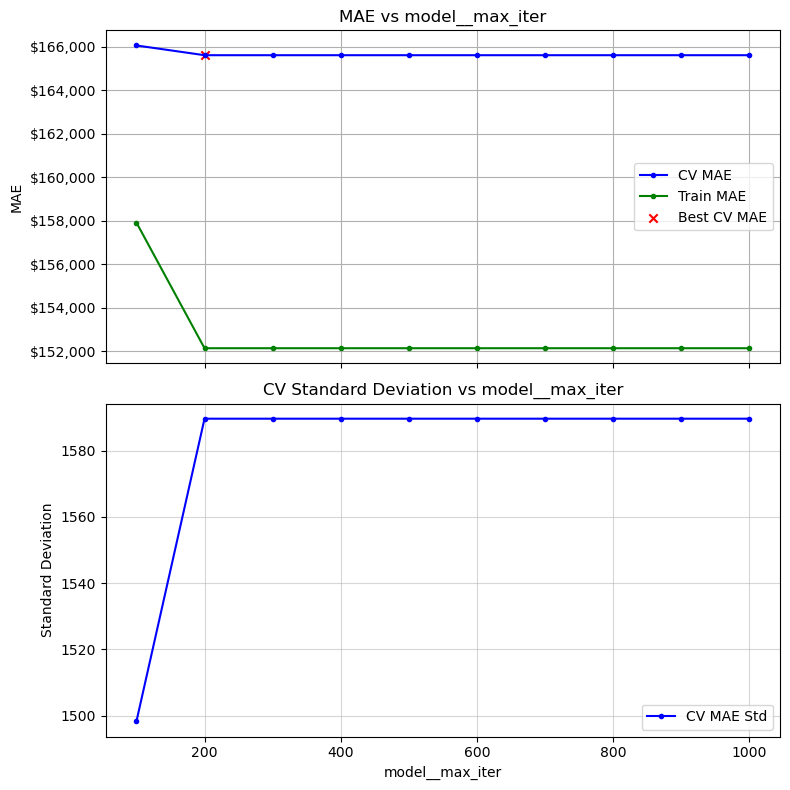

Execution Time: 00:00:27
Parameter max_iter = 200 MAE = $165,615


In [ ]:
param = 'max_iter'
parameter_list[param] = range(100,1001,100)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_iter: 100%|██████████| 10/10 [00:29<00:00,  2.97s/it]


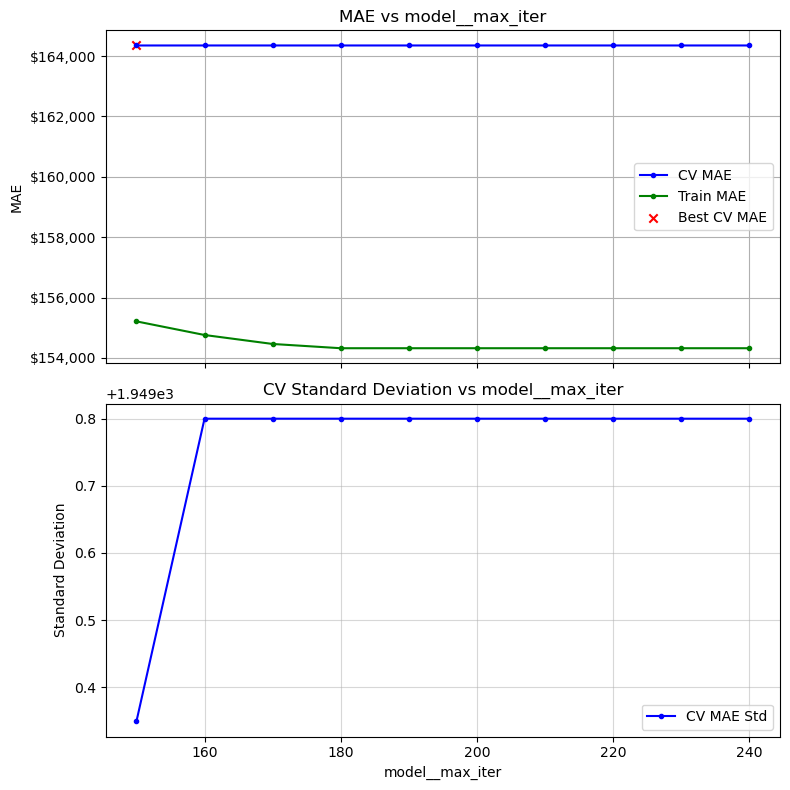

Execution Time: 00:00:29
Parameter max_iter = 150 MAE = $164,349


In [ ]:
param = 'max_iter'
parameter_list[param] = range(150,250,10)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =2
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_depth: 100%|██████████| 8/8 [00:20<00:00,  2.60s/it]


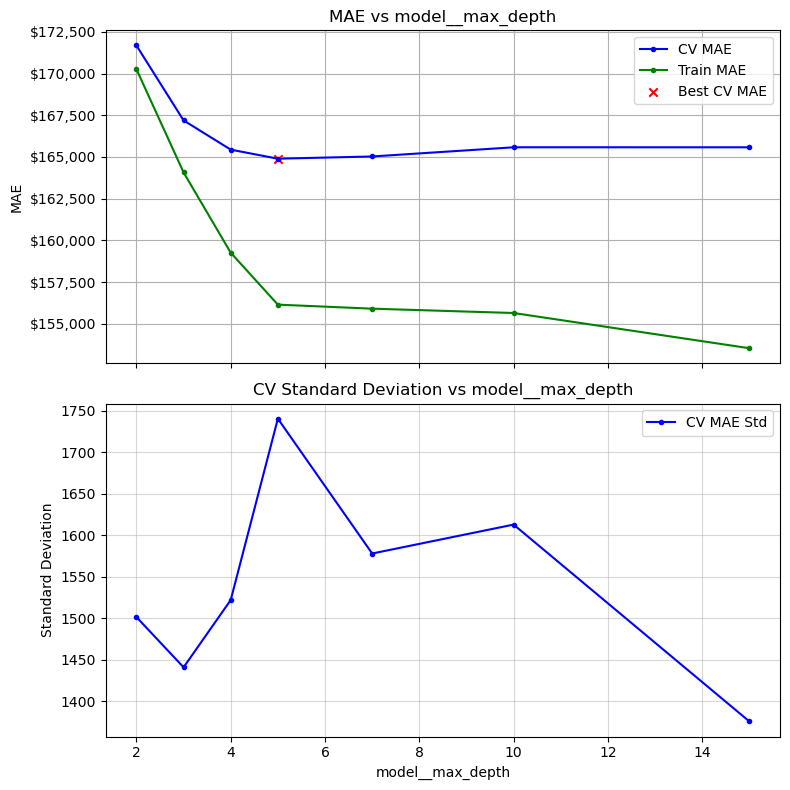

Execution Time: 00:00:21
Parameter max_depth = 5 MAE = $164,896


In [ ]:
param = 'max_depth'
parameter_list[param] = [2,3,4,5,7,10,15,None]

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_depth: 100%|██████████| 5/5 [00:21<00:00,  4.30s/it]


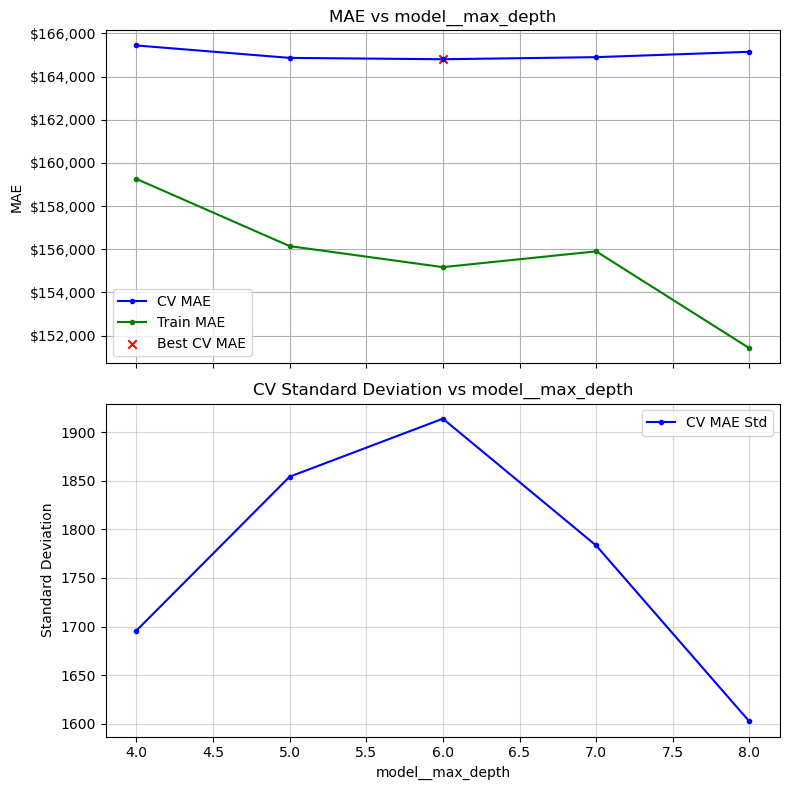

Execution Time: 00:00:21
Parameter max_depth = 6 MAE = $164,802


In [ ]:
param = 'max_depth'
parameter_list[param] = range(4,9)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =5
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_leaf_nodes: 100%|██████████| 14/14 [00:39<00:00,  2.84s/it]


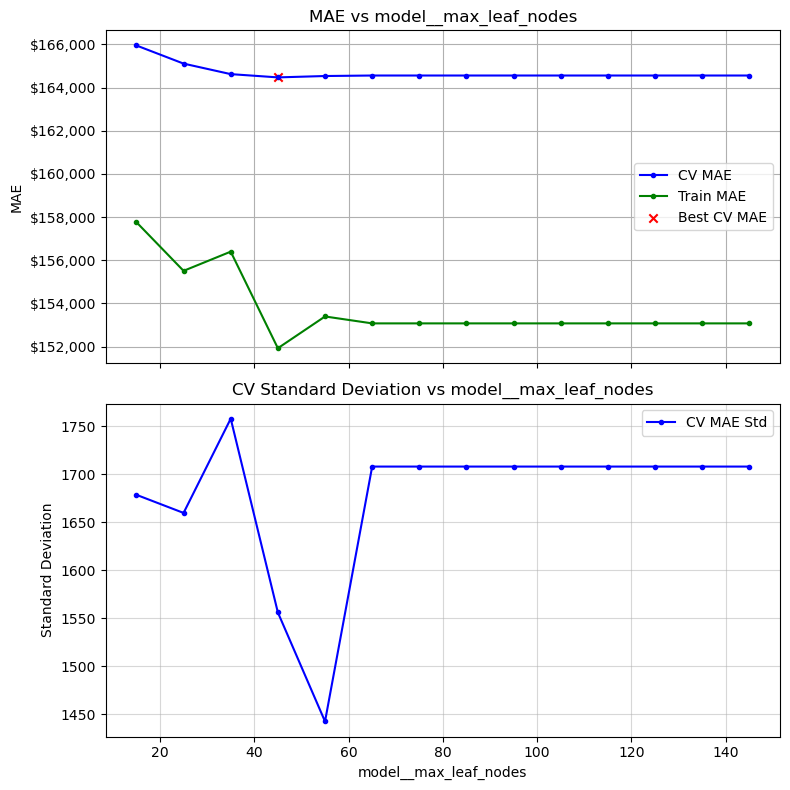

Execution Time: 00:00:39
Parameter max_leaf_nodes = 45 MAE = $164,469


In [ ]:
param = 'max_leaf_nodes'
parameter_list[param] = range(15,151,10)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_leaf_nodes: 100%|██████████| 4/4 [00:11<00:00,  2.79s/it]


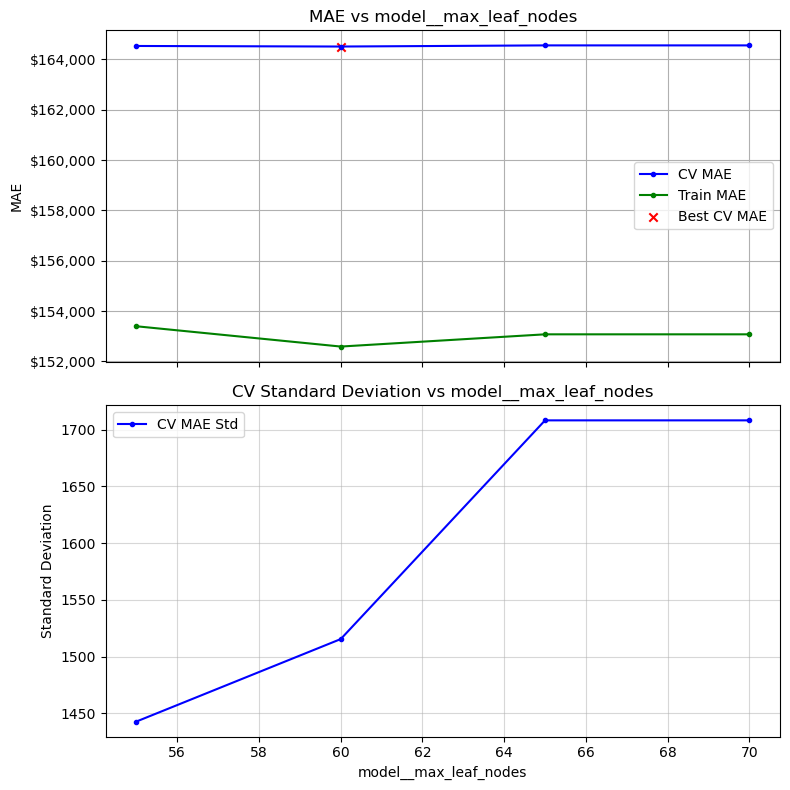

Execution Time: 00:00:11
Parameter max_leaf_nodes = 60 MAE = $164,510


In [ ]:
param = 'max_leaf_nodes'
parameter_list[param] = range(55,75,5)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__min_samples_leaf: 100%|██████████| 20/20 [01:02<00:00,  3.14s/it]


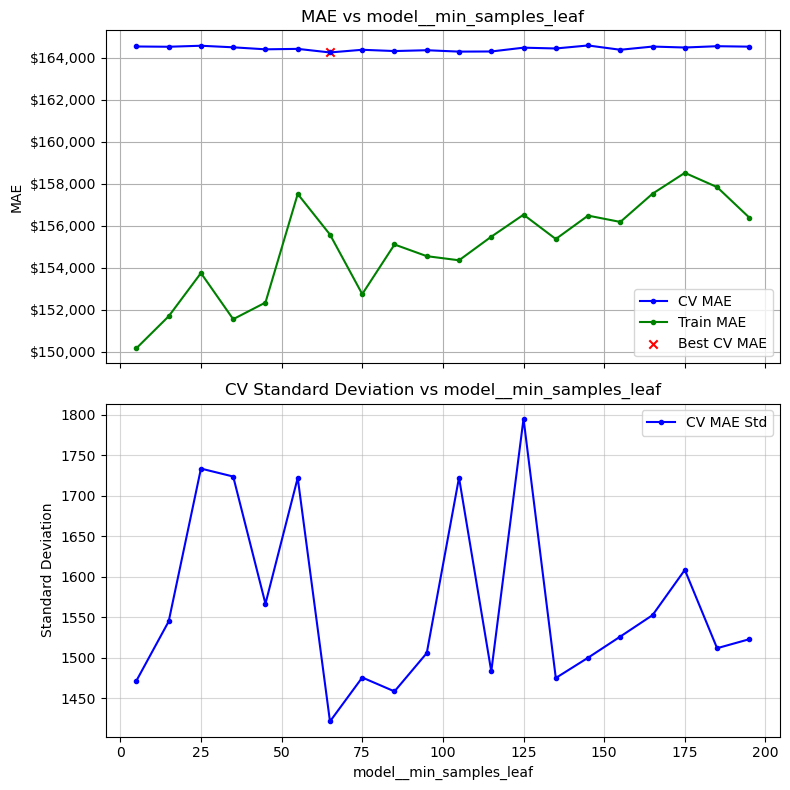

Execution Time: 00:01:03
Parameter min_samples_leaf = 65 MAE = $164,259


In [ ]:
param = 'min_samples_leaf'
parameter_list[param] = range(5,200,10)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__min_samples_leaf: 100%|██████████| 4/4 [00:10<00:00,  2.57s/it]


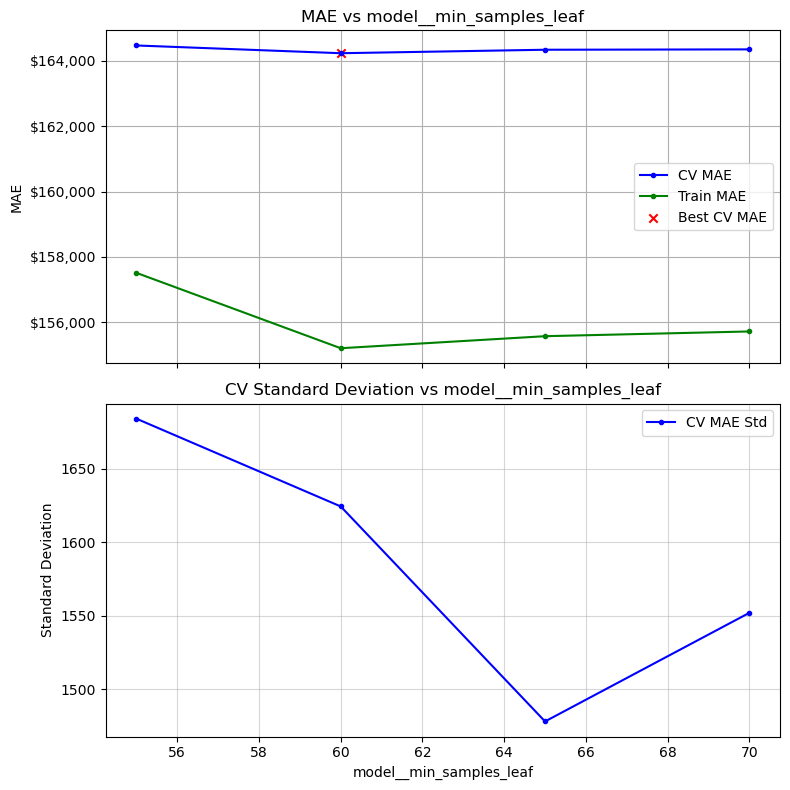

Execution Time: 00:00:10
Parameter min_samples_leaf = 60 MAE = $164,226


In [ ]:
param = 'min_samples_leaf'
parameter_list[param] = range(55,75,5)

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_features: 100%|██████████| 5/5 [00:18<00:00,  3.65s/it]


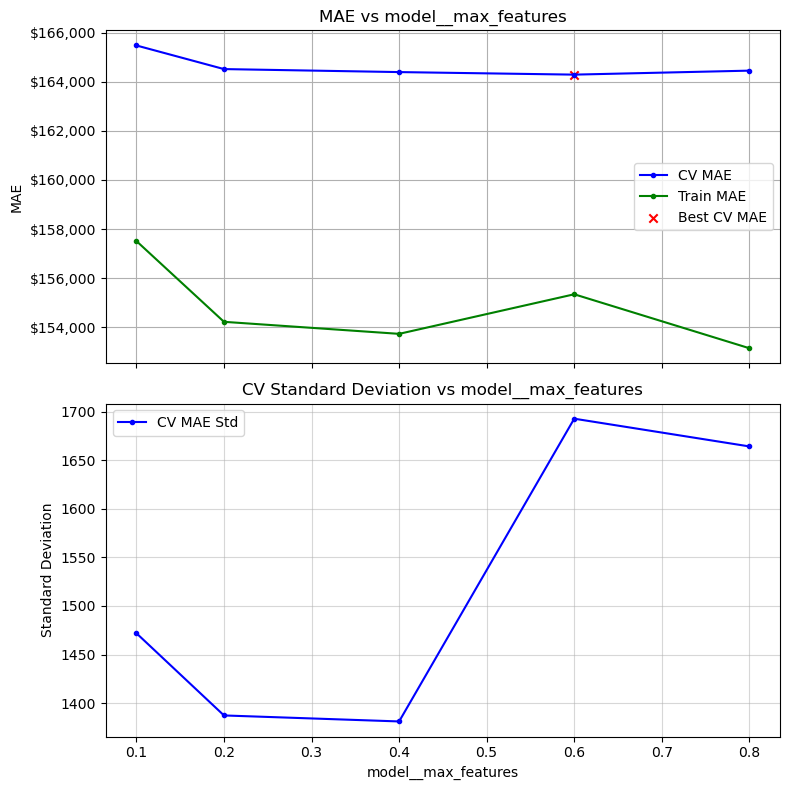

Execution Time: 00:00:18
Parameter max_features = 0.6 MAE = $164,289


In [ ]:
param = 'max_features'
parameter_list[param] = [.1,.2,.4,.6,.8]

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

Sweeping model__max_features: 100%|██████████| 5/5 [00:16<00:00,  3.21s/it]


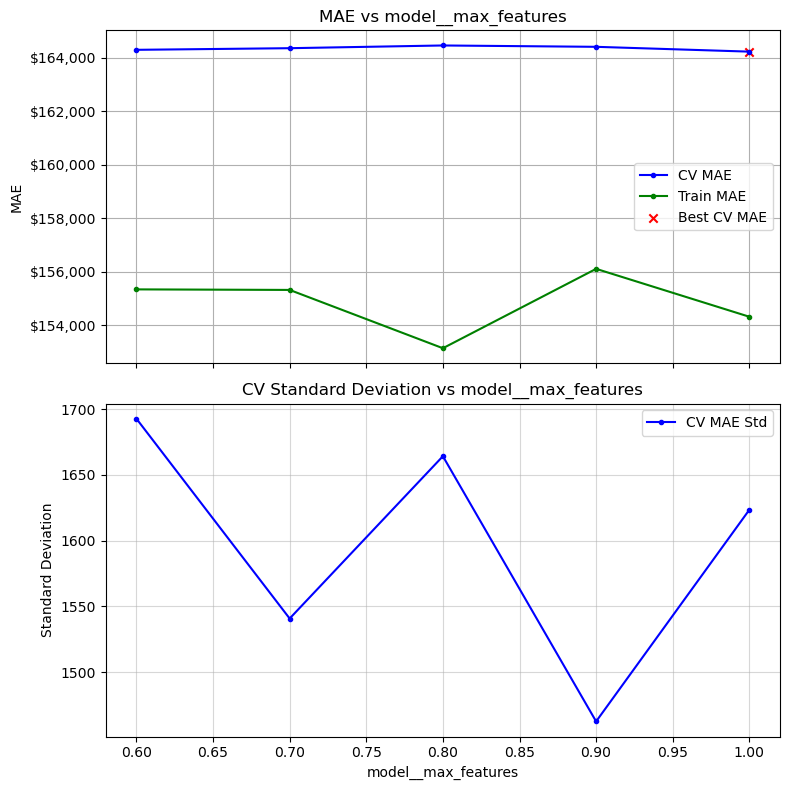

Execution Time: 00:00:16
Parameter max_features = 1.0 MAE = $164,222


In [ ]:
param = 'max_features'
parameter_list[param] = [.6,.7,.8,.9,1.0]

Params_GB = sweep_parameter(
                model                   =hist_pipeline,
                Parameters              =Params_GB,
                param                   =f"model__{param}",
                parameter_list          =parameter_list[param],
                X_train                 =X_train,
                y_train                 =y_train,
                verbose                 =True,
                show_mae                =True,
                show_std                =True,
                n_iter_no_change        =None,
                delta                   =0.001,
                n_jobs                  =-1,
                n_repeats               =3
            )
print(f"Parameter {param} = {Params_GB[f'model__{param}']} MAE = ${Params_GB['MAE_found']:,.0f}")

In [ ]:
from scipy.stats import randint, uniform

param_grid = {
    'model__max_iter'         : randint(100, 500),
    'model__max_depth'        : randint(4,9),
    'model__max_leaf_nodes'   : randint(40, 85),
    'model__min_samples_leaf' : randint(50, 100),
    'model__max_features'     : uniform(0.6, 0.4),
    'model__l2_regularization': uniform(0, 2.0),
    'model__learning_rate'    : uniform(0.01, 0.19)
}

rcv = RandomizedSearchCV(
    hist_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    scoring='neg_mean_absolute_error',
    cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state),
    n_jobs=-1,
    random_state=random_state,
    verbose=1
)

rcv.fit(X_train, y_train)
print(f"Best MAE: ${-rcv.best_score_:,.0f}")
print(f"Best params: {rcv.best_params_}")

Fitting 25 folds for each of 150 candidates, totalling 3750 fits
Best MAE: $163,726
Best params: {'model__l2_regularization': 0.5571806780639172, 'model__learning_rate': 0.043631992012581895, 'model__max_depth': 8, 'model__max_features': 0.8194861236829635, 'model__max_iter': 232, 'model__max_leaf_nodes': 80, 'model__min_samples_leaf': 61}


In [ ]:
pre_mae, pre_std, _  = run_model(hist_pipeline, X_train, y_train, n_repeats=5)
post_mae, post_std, _ = run_model(rcv.best_estimator_, X_train, y_train, n_repeats=5)

print(f"{'':20} {'MAE':>12}  {'± Std':>10}")
print(f"{'Pre-tuning':20} ${pre_mae:>11,.0f}  ${pre_std:>9,.0f}")
print(f"{'Post-tuning':20} ${post_mae:>11,.0f}  ${post_std:>9,.0f}")
print(f"{'Improvement':20} ${pre_mae - post_mae:>+11,.0f}")


                              MAE       ± Std
Pre-tuning           $    164,280  $    1,674
Post-tuning          $    163,726  $    1,667
Improvement          $       +554


#### Ridge Regression

#### MODEL 3 UPDATE HERE

### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
def eval_final_model(model, X_train, y_train, X_test, y_test, model_name):
    neg_mae_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring = 'neg_mean_absolute_error',
        cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state),
        n_jobs= -1
    )

    cv_mae = -np.mean(neg_mae_scores)
    cv_std = np.std(neg_mae_scores)

    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)

    metrics = {
        'Train MAE': mean_absolute_error(y_train, train_preds),
        'Test MAE': mean_absolute_error(y_test, test_preds),
        'cv_mae': cv_mae,
        'cv_std': cv_std
    }

    print(f"{model_name}")
    print(f"  {'CV MAE':<12} ${cv_mae:>11,.0f} ± ${cv_std:,.0f}")
    print(f"  {'Train MAE':<12} ${mean_absolute_error(y_train, train_preds):>11,.0f}")
    print(f"  {'Test MAE':<12} ${mean_absolute_error(y_test, test_preds):>11,.0f}")

    return metrics

In [ ]:
#Print out final evaluation for final HistGradientBoostedModel

HGB_results = eval_final_model(rcv.best_estimator_, X_train, y_train, X_test, y_test, 
                     model_name='HistGradientBoosting (Tuned)')

HistGradientBoosting (Tuned)
  CV MAE       $    163,726 ± $1,667
  Train MAE    $    154,237
  Test MAE     $    187,715


[('HistGradientBoosting', 166029.23940395113, 1672.9673125034578)]

### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here